In [1]:
import pandas as pd 
import os 
import numpy as np

# read mutation data 
maf = pd.read_csv('../data_csvs/mutations/mc3.v0.2.8.PUBLIC.maf', 
                 delimiter='\t', 
                 low_memory=False)
maf

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Variant_Classification,Variant_Type,...,ExAC_AF_NFE,ExAC_AF_OTH,ExAC_AF_SAS,GENE_PHENO,FILTER,COSMIC,CENTERS,CONTEXT,DBVS,NCALLERS
0,TACC2,0,.,GRCh37,10,123810032,123810032,+,Missense_Mutation,SNP,...,.,.,.,.,PASS,SITE|p.T38M|c.113C>T|3,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,GGACACGCCCG,by1000G,5
1,JAKMIP3,0,.,GRCh37,10,133967449,133967449,+,Silent,SNP,...,.,.,.,.,PASS,NONE,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,CTGGACGAGGA,byFrequency,5
2,PANX3,0,.,GRCh37,11,124489539,124489539,+,Missense_Mutation,SNP,...,.,.,.,.,PASS,SITE|p.R296Q|c.887G>A|3,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,ATGTCGGTGGG,.,5
3,SPI1,0,.,GRCh37,11,47380512,47380512,+,Missense_Mutation,SNP,...,.,.,.,.,PASS,NONE,RADIA|MUSE,GGCTGGGGACA,.,2
4,NAALAD2,0,.,GRCh37,11,89868837,89868837,+,Missense_Mutation,SNP,...,.,.,.,.,PASS,SITE|p.R65C|c.193C>T|4,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,TTCTTCGGTAA,.,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3600958,THOC2,0,.,GRCh37,X,122829875,122829875,+,Missense_Mutation,SNP,...,.,.,.,.,PASS,NONE,RADIA|MUSE|VARSCANS,CCTATTAAAGA,.,3
3600959,SLC25A14,0,.,GRCh37,X,129498779,129498779,+,Intron,SNP,...,.,.,.,.,PASS,NONE,SOMATICSNIPER|RADIA|MUTECT|MUSE|VARSCANS,AAAAAGCCTCT,.,5
3600960,FGF13,0,.,GRCh37,X,137714160,137714160,+,3'Flank,SNP,...,.,.,.,.,PASS,NONE,MUTECT|MUSE,AGTTCCTGTCT,.,2
3600961,XIST,0,.,GRCh37,X,73044379,73044379,+,RNA,SNP,...,.,.,.,.,PASS,NONE,RADIA|MUTECT|MUSE|VARSCANS,TTAAACCCTTG,.,4


In [3]:
import pandas as pd

print("=== Overlap Analysis between Hallmark Genes and BRCA Mutated Genes (matched to RNA patients) ===")

# 1. Load Hallmark genes
hallmarks = pd.read_csv('../data_csvs/rna/metadata/hallmarks_signatures.csv').values.flatten()
hallmarks = hallmarks[~pd.isnull(hallmarks)]
hallmarks = set(pd.unique(hallmarks))
print(f"Total number of Hallmark genes: {len(hallmarks):,}")

# 2. Load RNA sample list (BRCA)
print("Loading BRCA RNA sample list...")
rna_samples = pd.read_csv('../data_csvs/rna/hallmarks/BRCA/rna_clean.csv')

# Extract first 15 characters as patient ID
rna_samples['patient_id'] = rna_samples['sample'].str[:15]
target_patients = set(rna_samples['patient_id'].unique())
print(f"Number of patients with RNA samples: {len(target_patients):,}")

# 3. Extract patient ID from MAF
maf['patient_id'] = maf['Tumor_Sample_Barcode'].str[:15]
print(f"Total number of MAF records: {len(maf):,}")
print(f"Total number of MAF patients: {maf['patient_id'].nunique():,}")

# 4. Filter MAF records for matching patients
maf_brca = maf[maf['patient_id'].isin(target_patients)].copy()
print(f"Number of MAF records after filtering: {len(maf_brca):,}")
print(f"Number of patients after filtering: {maf_brca['patient_id'].nunique():,}")

# 5. Get the set of mutated genes
brca_mutated_genes = set(maf_brca['Hugo_Symbol'].unique())

# 6. Compute overlaps
overlap_genes = hallmarks & brca_mutated_genes
hallmark_only = hallmarks - brca_mutated_genes
brca_only = brca_mutated_genes - hallmarks

# 7. Print summary statistics
print(f"\nTotal number of mutated genes in BRCA: {len(brca_mutated_genes):,}")
print(f"Number of overlapping genes: {len(overlap_genes):,}")
print(f"Overlap proportion: {len(overlap_genes)/len(hallmarks)*100:.1f}% (Hallmark)")
print(f"Overlap proportion: {len(overlap_genes)/len(brca_mutated_genes)*100:.1f}% (BRCA mutations)")

print(f"\nNumber of genes only in Hallmark: {len(hallmark_only):,}")
print(f"Number of genes only in BRCA mutations: {len(brca_only):,}")

# 8. Display top mutated genes
gene_counts = maf_brca['Hugo_Symbol'].value_counts().head(10)
print("\nTop 10 most frequently mutated genes in BRCA:")
for gene, count in gene_counts.items():
    in_hallmark = "✓" if gene in hallmarks else "✗"
    print(f"  {in_hallmark} {gene}: {count:,} mutations")


=== Overlap Analysis between Hallmark Genes and BRCA Mutated Genes (matched to RNA patients) ===
Total number of Hallmark genes: 4,241
Loading BRCA RNA sample list...
Number of patients with RNA samples: 1,218
Total number of MAF records: 3,600,963
Total number of MAF patients: 10,295
Number of MAF records after filtering: 134,947
Number of patients after filtering: 1,024

Total number of mutated genes in BRCA: 18,905
Number of overlapping genes: 4,051
Overlap proportion: 95.5% (Hallmark)
Overlap proportion: 21.4% (BRCA mutations)

Number of genes only in Hallmark: 190
Number of genes only in BRCA mutations: 14,854

Top 10 most frequently mutated genes in BRCA:
  ✗ TTN: 446 mutations
  ✓ PIK3CA: 425 mutations
  ✓ TP53: 376 mutations
  ✗ MUC16: 213 mutations
  ✓ CDH1: 144 mutations
  ✓ MAP3K1: 142 mutations
  ✓ GATA3: 140 mutations
  ✗ KMT2C: 132 mutations
  ✓ RYR2: 120 mutations
  ✓ SYNE1: 118 mutations


In [4]:
import pandas as pd

print("=== Overlap Analysis between Hallmark Genes and LUAD Mutated Genes (matched to RNA patients) ===")

# 1. Load Hallmark genes
hallmarks = pd.read_csv('../data_csvs/rna/metadata/hallmarks_signatures.csv').values.flatten()
hallmarks = hallmarks[~pd.isnull(hallmarks)]
hallmarks = set(pd.unique(hallmarks))
print(f"Total number of Hallmark genes: {len(hallmarks):,}")

# 2. Load RNA sample list (LUAD)
print("Loading LUAD RNA sample list...")
rna_samples = pd.read_csv('../data_csvs/rna/hallmarks/LUAD/rna_clean.csv')

# Extract first 15 characters as patient ID
rna_samples['patient_id'] = rna_samples['sample'].str[:15]
target_patients = set(rna_samples['patient_id'].unique())
print(f"Number of patients with RNA samples: {len(target_patients):,}")

# 3. Extract patient ID from MAF (assuming maf variable has already been loaded)
maf['patient_id'] = maf['Tumor_Sample_Barcode'].str[:15]
print(f"Total number of MAF records: {len(maf):,}")
print(f"Total number of MAF patients: {maf['patient_id'].nunique():,}")

# 4. Filter MAF records for matching patients
maf_luad = maf[maf['patient_id'].isin(target_patients)].copy()
print(f"Number of MAF records after filtering: {len(maf_luad):,}")
print(f"Number of patients after filtering: {maf_luad['patient_id'].nunique():,}")

# 5. Get the set of mutated genes
luad_mutated_genes = set(maf_luad['Hugo_Symbol'].unique())

# 6. Compute overlaps
overlap_genes = hallmarks & luad_mutated_genes
hallmark_only = hallmarks - luad_mutated_genes
luad_only = luad_mutated_genes - hallmarks

# 7. Print summary statistics
print(f"\nTotal number of mutated genes in LUAD: {len(luad_mutated_genes):,}")
print(f"Number of overlapping genes: {len(overlap_genes):,}")
print(f"Overlap proportion: {len(overlap_genes)/len(hallmarks)*100:.1f}% (Hallmark)")
print(f"Overlap proportion: {len(overlap_genes)/len(luad_mutated_genes)*100:.1f}% (LUAD mutations)")

print(f"\nNumber of genes only in Hallmark: {len(hallmark_only):,}")
print(f"Number of genes only in LUAD mutations: {len(luad_only):,}")

# 8. Display top mutated genes
gene_counts = maf_luad['Hugo_Symbol'].value_counts().head(10)
print("\nTop 10 most frequently mutated genes in LUAD:")
for gene, count in gene_counts.items():
    in_hallmark = "✓" if gene in hallmarks else "✗"
    print(f"  {in_hallmark} {gene}: {count:,} mutations")


=== Overlap Analysis between Hallmark Genes and LUAD Mutated Genes (matched to RNA patients) ===
Total number of Hallmark genes: 4,241
Loading LUAD RNA sample list...
Number of patients with RNA samples: 576
Total number of MAF records: 3,600,963
Total number of MAF patients: 10,295
Number of MAF records after filtering: 223,804
Number of patients after filtering: 513

Total number of mutated genes in LUAD: 18,718
Number of overlapping genes: 4,083
Overlap proportion: 96.3% (Hallmark)
Overlap proportion: 21.8% (LUAD mutations)

Number of genes only in Hallmark: 158
Number of genes only in LUAD mutations: 14,635

Top 10 most frequently mutated genes in LUAD:
  ✗ TTN: 938 mutations
  ✗ MUC16: 565 mutations
  ✓ RYR2: 494 mutations
  ✗ CSMD3: 484 mutations
  ✗ LRP1B: 392 mutations
  ✗ USH2A: 374 mutations
  ✗ ZFHX4: 348 mutations
  ✓ TP53: 311 mutations
  ✗ XIRP2: 271 mutations
  ✗ FLG: 271 mutations


In [5]:
import pandas as pd

print("=== Overlap Analysis between Hallmark Genes and STAD Mutated Genes (matched to RNA patients) ===")

# 1. Load Hallmark genes
hallmarks = pd.read_csv('../data_csvs/rna/metadata/hallmarks_signatures.csv').values.flatten()
hallmarks = hallmarks[~pd.isnull(hallmarks)]
hallmarks = set(pd.unique(hallmarks))
print(f"Total number of Hallmark genes: {len(hallmarks):,}")

# 2. Load RNA sample list (STAD)
print("Loading STAD RNA sample list...")
rna_samples = pd.read_csv('../data_csvs/rna/hallmarks/STAD/rna_clean.csv')

# Extract first 15 characters as patient ID
rna_samples['patient_id'] = rna_samples['sample'].str[:15]
target_patients = set(rna_samples['patient_id'].unique())
print(f"Number of patients with RNA samples: {len(target_patients):,}")

# 3. Extract patient ID from MAF (assuming maf variable has already been loaded)
maf['patient_id'] = maf['Tumor_Sample_Barcode'].str[:15]
print(f"Total number of MAF records: {len(maf):,}")
print(f"Total number of MAF patients: {maf['patient_id'].nunique():,}")

# 4. Filter MAF records for matching patients
maf_stad = maf[maf['patient_id'].isin(target_patients)].copy()
print(f"Number of MAF records after filtering: {len(maf_stad):,}")
print(f"Number of patients after filtering: {maf_stad['patient_id'].nunique():,}")

# 5. Get the set of mutated genes
stad_mutated_genes = set(maf_stad['Hugo_Symbol'].unique())

# 6. Compute overlaps
overlap_genes = hallmarks & stad_mutated_genes
hallmark_only = hallmarks - stad_mutated_genes
stad_only = stad_mutated_genes - hallmarks

# 7. Print summary statistics
print(f"\nTotal number of mutated genes in STAD: {len(stad_mutated_genes):,}")
print(f"Number of overlapping genes: {len(overlap_genes):,}")
print(f"Overlap proportion: {len(overlap_genes)/len(hallmarks)*100:.1f}% (Hallmark)")
print(f"Overlap proportion: {len(overlap_genes)/len(stad_mutated_genes)*100:.1f}% (STAD mutations)")

print(f"\nNumber of genes only in Hallmark: {len(hallmark_only):,}")
print(f"Number of genes only in STAD mutations: {len(stad_only):,}")

# 8. Display top mutated genes
gene_counts = maf_stad['Hugo_Symbol'].value_counts().head(10)
print("\nTop 10 most frequently mutated genes in STAD:")
for gene, count in gene_counts.items():
    in_hallmark = "✓" if gene in hallmarks else "✗"
    print(f"  {in_hallmark} {gene}: {count:,} mutations")


=== Overlap Analysis between Hallmark Genes and STAD Mutated Genes (matched to RNA patients) ===
Total number of Hallmark genes: 4,241
Loading STAD RNA sample list...
Number of patients with RNA samples: 450
Total number of MAF records: 3,600,963
Total number of MAF patients: 10,295
Number of MAF records after filtering: 231,248
Number of patients after filtering: 412

Total number of mutated genes in STAD: 18,919
Number of overlapping genes: 4,138
Overlap proportion: 97.6% (Hallmark)
Overlap proportion: 21.9% (STAD mutations)

Number of genes only in Hallmark: 103
Number of genes only in STAD mutations: 14,781

Top 10 most frequently mutated genes in STAD:
  ✗ TTN: 937 mutations
  ✗ MUC16: 361 mutations
  ✓ SYNE1: 240 mutations
  ✓ TP53: 235 mutations
  ✗ LRP1B: 227 mutations
  ✗ OBSCN: 218 mutations
  ✗ FAT4: 210 mutations
  ✗ FLG: 203 mutations
  ✗ CSMD3: 202 mutations
  ✓ PCLO: 181 mutations


In [7]:
import pandas as pd

print("=== Overlap Analysis between Hallmark Genes and KIRC Mutated Genes (matched to RNA patients) ===")

# 1. Load Hallmark genes
hallmarks = pd.read_csv('../data_csvs/rna/metadata/hallmarks_signatures.csv').values.flatten()
hallmarks = hallmarks[~pd.isnull(hallmarks)]
hallmarks = set(pd.unique(hallmarks))
print(f"Total number of Hallmark genes: {len(hallmarks):,}")

# 2. Load RNA sample list (KIRC)
print("Loading KIRC RNA sample list...")
rna_samples = pd.read_csv('../data_csvs/rna/hallmarks/KIRC/rna_clean.csv')

# Extract first 15 characters as patient ID
rna_samples['patient_id'] = rna_samples['sample'].str[:15]
target_patients = set(rna_samples['patient_id'].unique())
print(f"Number of patients with RNA samples: {len(target_patients):,}")

# 3. Extract patient ID from MAF (assuming maf variable has already been loaded)
maf['patient_id'] = maf['Tumor_Sample_Barcode'].str[:15]
print(f"Total number of MAF records: {len(maf):,}")
print(f"Total number of MAF patients: {maf['patient_id'].nunique():,}")

# 4. Filter MAF records for matching patients
maf_kirc = maf[maf['patient_id'].isin(target_patients)].copy()
print(f"Number of MAF records after filtering: {len(maf_kirc):,}")
print(f"Number of patients after filtering: {maf_kirc['patient_id'].nunique():,}")

# 5. Get the set of mutated genes
kirc_mutated_genes = set(maf_kirc['Hugo_Symbol'].unique())

# 6. Compute overlaps
overlap_genes = hallmarks & kirc_mutated_genes
hallmark_only = hallmarks - kirc_mutated_genes
kirc_only = kirc_mutated_genes - hallmarks

# 7. Print summary statistics
print(f"\nTotal number of mutated genes in KIRC: {len(kirc_mutated_genes):,}")
print(f"Number of overlapping genes: {len(overlap_genes):,}")
print(f"Overlap proportion: {len(overlap_genes)/len(hallmarks)*100:.1f}% (Hallmark)")
print(f"Overlap proportion: {len(overlap_genes)/len(kirc_mutated_genes)*100:.1f}% (KIRC mutations)")

print(f"\nNumber of genes only in Hallmark: {len(hallmark_only):,}")
print(f"Number of genes only in KIRC mutations: {len(kirc_only):,}")

# 8. Display top mutated genes
gene_counts = maf_kirc['Hugo_Symbol'].value_counts().head(10)
print("\nTop 10 most frequently mutated genes in KIRC:")
for gene, count in gene_counts.items():
    in_hallmark = "✓" if gene in hallmarks else "✗"
    print(f"  {in_hallmark} {gene}: {count:,} mutations")


=== Overlap Analysis between Hallmark Genes and KIRC Mutated Genes (matched to RNA patients) ===
Total number of Hallmark genes: 4,241
Loading KIRC RNA sample list...
Number of patients with RNA samples: 606
Total number of MAF records: 3,600,963
Total number of MAF patients: 10,295
Number of MAF records after filtering: 31,821
Number of patients after filtering: 368

Total number of mutated genes in KIRC: 12,865
Number of overlapping genes: 2,931
Overlap proportion: 69.1% (Hallmark)
Overlap proportion: 22.8% (KIRC mutations)

Number of genes only in Hallmark: 1,310
Number of genes only in KIRC mutations: 9,934

Top 10 most frequently mutated genes in KIRC:
  ✓ VHL: 186 mutations
  ✗ PBRM1: 170 mutations
  ✗ TTN: 131 mutations
  ✗ SETD2: 59 mutations
  ✗ MUC16: 45 mutations
  ✗ BAP1: 42 mutations
  ✓ MTOR: 35 mutations
  ✓ DST: 30 mutations
  ✗ LRP2: 25 mutations
  ✗ KDM5C: 24 mutations


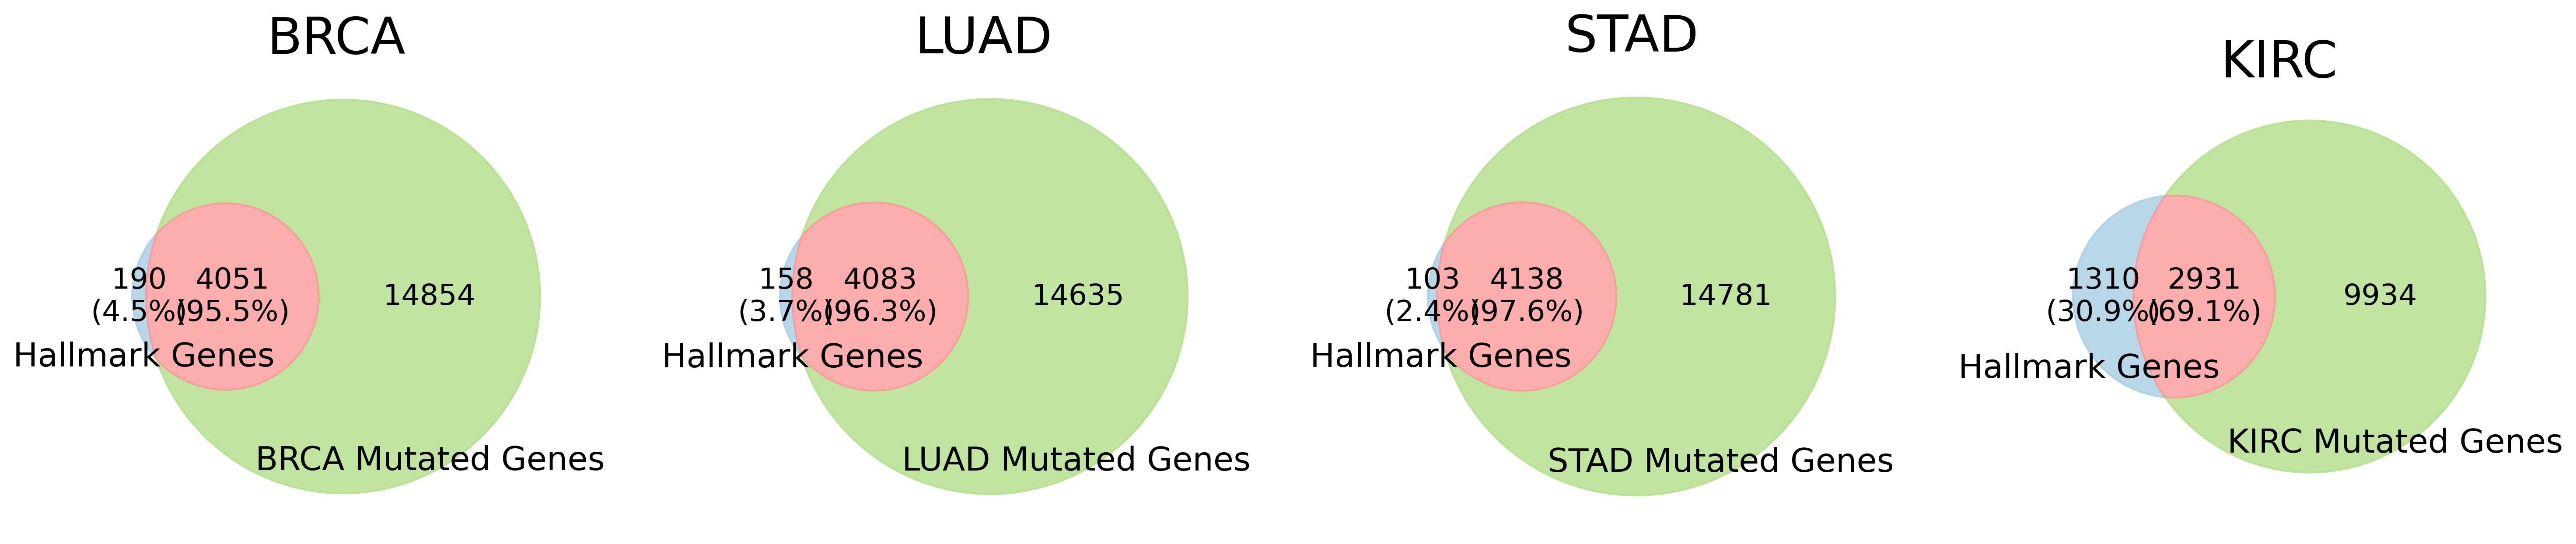

In [8]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Cancer data
cancers = [
    {"name": "BRCA", "mutated_genes": 18905, "overlap": 4051},
    {"name": "LUAD", "mutated_genes": 18718, "overlap": 4083},
    {"name": "STAD", "mutated_genes": 18919, "overlap": 4138},
    {"name": "KIRC", "mutated_genes": 12865, "overlap": 2931},
]

hallmark_genes = 4241

# Set up figure
plt.figure(figsize=(20, 5), dpi=300)

# Colors for regions
colors = {
    "only_hallmark": "#a6cee3",
    "only_mutated": "#b2df8a",
    "overlap": "#fb9a99"
}

# Loop over cancers
for idx, cancer in enumerate(cancers, start=1):
    only_hallmark = hallmark_genes - cancer["overlap"]
    only_mutated = cancer["mutated_genes"] - cancer["overlap"]
    overlap = cancer["overlap"]

    # Calculate overlap proportion
    overlap_pct = overlap / hallmark_genes * 100

    ax = plt.subplot(1, 4, idx)
    v = venn2(
        subsets=(only_hallmark, only_mutated, overlap),
        set_labels=('Hallmark Genes', f'{cancer["name"]} Mutated Genes')
    )

    # Colors
    v.get_patch_by_id('10').set_color(colors["only_hallmark"])
    v.get_patch_by_id('01').set_color(colors["only_mutated"])
    v.get_patch_by_id('11').set_color(colors["overlap"])

    # Transparency
    for patch in v.patches:
        if patch:
            patch.set_alpha(0.8)

    # Make set labels bigger
    for text in v.set_labels:
        text.set_fontsize(18)

    # Move left label up
    left_label = v.set_labels[0]
    left_label.set_y(left_label.get_position()[1] + 0.18)
    left_label.set_x(left_label.get_position()[0] + 0.14)
    # Move right label up
    right_label = v.set_labels[1]
    right_label.set_y(right_label.get_position()[1] + 0.18)
    right_label.set_x(right_label.get_position()[0] - 0.25)

    # Custom numeric labels (with larger font)
    if v.get_label_by_id('10'):
        v.get_label_by_id('10').set_text(f'{only_hallmark}\n({only_hallmark / hallmark_genes * 100:.1f}%)')
        v.get_label_by_id('10').set_fontsize(16)
    if v.get_label_by_id('01'):
        v.get_label_by_id('01').set_text(f'{only_mutated}')
        v.get_label_by_id('01').set_fontsize(16)
    if v.get_label_by_id('11'):
        v.get_label_by_id('11').set_text(f'{overlap}\n({overlap_pct:.1f}%)')
        v.get_label_by_id('11').set_fontsize(16)

    # Subplot title
    plt.title(f'{cancer["name"]}', fontsize=28)

plt.tight_layout()
plt.show()
